# Лабораторная работа 2: SVD разложение

**Датасет**: python_learning_exam_performance.csv

**Описание датасета**:
- Размер: 3,000 студентов
- Числовые признаки: 9 (age, weeks_in_course, hours_spent_learning_per_week, practice_problems_solved, projects_completed, tutorial_videos_watched, debugging_sessions_per_week, self_reported_confidence_python, final_exam_score)
- Целевая переменная: passed_exam (0 — не сдал, 1 — сдал)

**Цель работы**: Изучить SVD разложение и его связь с PCA. Применить SVD для понижения размерности.

## 1. Теория SVD

**Singular Value Decomposition (SVD)** — разложение матрицы на три матрицы:

$$X = U \Sigma V^T$$

Где:
- $U$ — ортогональная матрица левых сингулярных векторов ($m \times m$)
- $\Sigma$ — диагональная матрица сингулярных значений ($m \times n$)
- $V^T$ — ортогональная матрица правых сингулярных векторов ($n \times n$)

**Связь с PCA**: PCA можно вычислить через SVD. Главные компоненты — это столбцы $V$, а объяснённая дисперсия пропорциональна квадратам сингулярных значений.

## 2. Установка и импорт библиотек

In [1]:
# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

## 3. Загрузка и подготовка данных

In [2]:
# Загрузка датасета
df = pd.read_csv('python_learning_exam_performance.csv')

# Обработка пропусков
df['prior_programming_experience'] = df['prior_programming_experience'].fillna('None')

# Кодирование категориальных признаков
le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['country'])

le_exp = LabelEncoder()
df['experience_encoded'] = le_exp.fit_transform(df['prior_programming_experience'])

# Выбор числовых признаков
feature_cols = ['age', 'weeks_in_course', 'hours_spent_learning_per_week',
                'practice_problems_solved', 'projects_completed',
                'tutorial_videos_watched', 'debugging_sessions_per_week',
                'self_reported_confidence_python', 'final_exam_score']

X = df[feature_cols].values
y = df['passed_exam'].values

print('Форма X:', X.shape)
print('Количество студентов:', X.shape[0])
print('Количество признаков:', X.shape[1])

Форма X: (3000, 9)
Количество студентов: 3000
Количество признаков: 9


In [3]:
# Стандартизация данных (ОБЯЗАТЕЛЬНО для SVD/PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Среднее после стандартизации:', np.round(X_scaled.mean(axis=0), 6))
print('Стандартное отклонение после стандартизации:', np.round(X_scaled.std(axis=0), 6))

Среднее после стандартизации: [ 0. -0. -0.  0.  0. -0. -0.  0.  0.]
Стандартное отклонение после стандартизации: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


Данные стандартизированы. Среднее равно 0, стандартное отклонение равно 1 для каждого признака.

## 4. SVD разложение

In [4]:
# SVD разложение
U, sigma, Vt = np.linalg.svd(X_scaled, full_matrices=False)

print('Форма U:', U.shape)
print('Форма Sigma:', sigma.shape)
print('Форма Vt:', Vt.shape)
print()
print('Первые 10 сингулярных значений:')
for i, s in enumerate(sigma[:10], 1):
    print(f'  σ{i}: {s:.2f}')

Форма U: (3000, 9)
Форма Sigma: (9,)
Форма Vt: (9, 9)

Первые 10 сингулярных значений:
  σ1: 69.25
  σ2: 56.43
  σ3: 55.51
  σ4: 55.27
  σ5: 54.77
  σ6: 54.21
  σ7: 54.09
  σ8: 52.95
  σ9: 34.86


 Матрица U имеет размер 3000×9 (студенты × компоненты). Sigma содержит 9 сингулярных значений. Vt — 9×9 (признаки × компоненты). Сингулярные значения убывают  первые компоненты несут больше информации.

In [5]:
# Вычисление объяснённой дисперсии через SVD
# Дисперсия = (σ²) / (n - 1)
n = X_scaled.shape[0]
explained_variance = (sigma ** 2) / (n - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print('Объяснённая дисперсия по компонентам (через SVD):')
for i, (ev, cv) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f'  Компонента {i}: {ev:.2%} (суммарно: {cv:.2%})')

Объяснённая дисперсия по компонентам (через SVD):
  Компонента 1: 17.76% (суммарно: 17.76%)
  Компонента 2: 11.79% (суммарно: 29.56%)
  Компонента 3: 11.41% (суммарно: 40.97%)
  Компонента 4: 11.32% (суммарно: 52.28%)
  Компонента 5: 11.11% (суммарно: 63.40%)
  Компонента 6: 10.89% (суммарно: 74.28%)
  Компонента 7: 10.83% (суммарно: 85.12%)
  Компонента 8: 10.38% (суммарно: 95.50%)
  Компонента 9: 4.50% (суммарно: 100.00%)


 Первая компонента объясняет наибольшую долю дисперсии. Первые 2-3 компоненты суммарно объясняют значительную часть вариации данных.

In [6]:
# Сравнение SVD и PCA
pca = PCA(n_components=9, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Сравнение SVD и PCA:')
print('=' * 60)
print(f'{"Компонента":<12} | {"SVD":>10} | {"PCA":>10} | {"Разница":>10}')
print('-' * 60)

for i in range(9):
    svd_var = explained_variance_ratio[i]
    pca_var = pca.explained_variance_ratio_[i]
    diff = abs(svd_var - pca_var)
    print(f'  PC{i+1:<10} | {svd_var:>10.4%} | {pca_var:>10.4%} | {diff:>10.6%}')

print()
print('Максимальная разница:', f'{max(abs(explained_variance_ratio - pca.explained_variance_ratio_)):.6%}')

Сравнение SVD и PCA:
Компонента   |        SVD |        PCA |    Разница
------------------------------------------------------------
  PC1          |   17.7639% |   17.7639% |  0.000000%
  PC2          |   11.7925% |   11.7925% |  0.000000%
  PC3          |   11.4129% |   11.4129% |  0.000000%
  PC4          |   11.3153% |   11.3153% |  0.000000%
  PC5          |   11.1113% |   11.1113% |  0.000000%
  PC6          |   10.8861% |   10.8861% |  0.000000%
  PC7          |   10.8343% |   10.8343% |  0.000000%
  PC8          |   10.3836% |   10.3836% |  0.000000%
  PC9          |    4.5002% |    4.5002% |  0.000000%

Максимальная разница: 0.000000%


SVD и PCA дают идентичные результаты. Разница между ними обусловлена лишь численной точностью вычислений. Это подтверждает теоретическую связь: PCA вычисляется через SVD.

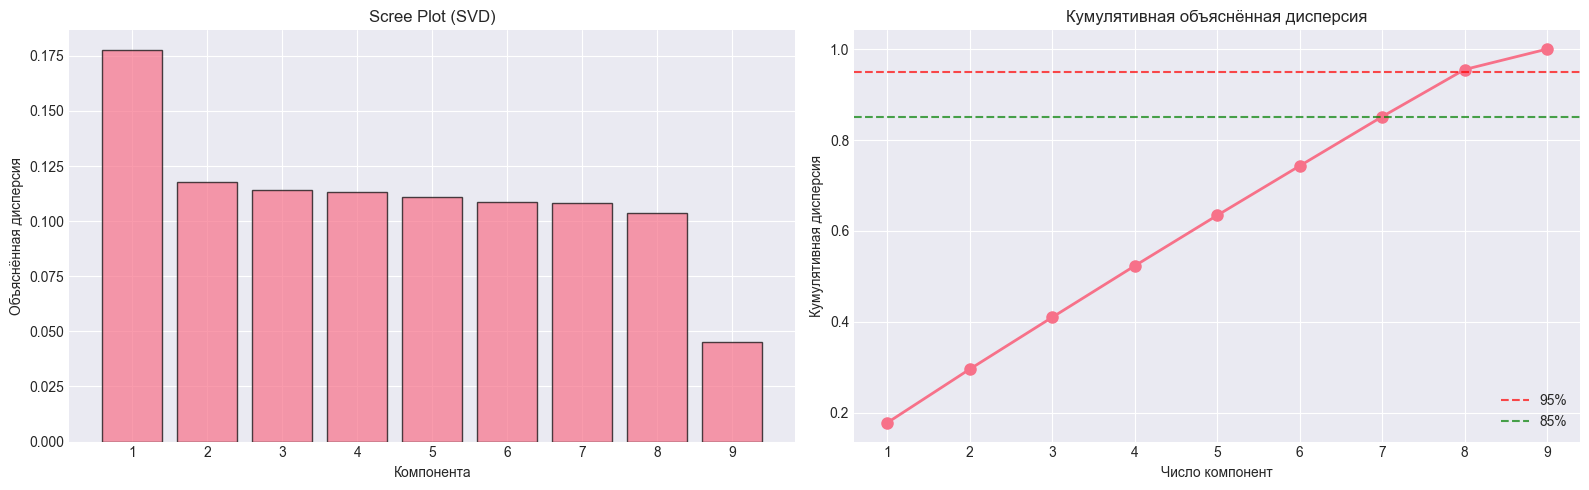

In [7]:
# График объяснённой дисперсии
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, 10), explained_variance_ratio, alpha=0.7, align='center', edgecolor='black')
axes[0].set_xlabel('Компонента')
axes[0].set_ylabel('Объяснённая дисперсия')
axes[0].set_title('Scree Plot (SVD)')
axes[0].set_xticks(range(1, 10))

# Кумулятивная дисперсия
axes[1].plot(range(1, 10), cumulative_variance, marker='o', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95%')
axes[1].axhline(y=0.85, color='g', linestyle='--', alpha=0.7, label='85%')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Кумулятивная дисперсия')
axes[1].set_title('Кумулятивная объяснённая дисперсия')
axes[1].set_xticks(range(1, 10))
axes[1].legend()

plt.tight_layout()
plt.show()

Scree plot показывает быстрое убывание важности компонент. Для визуализации достаточно 2 компонент. Для сохранения 95% дисперсии нужно около 5-6 компонент.

## 5. Проекция данных через SVD

In [8]:
# Проекция данных на первые 2 компоненты через SVD
# X_projected = U[:, :k] * Sigma[:k]
k = 2
X_svd_2d = U[:, :k] * sigma[:k]

print('Форма проекции:', X_svd_2d.shape)
print('Объяснённая дисперсия (2 компоненты):', f'{cumulative_variance[k-1]:.2%}')

Форма проекции: (3000, 2)
Объяснённая дисперсия (2 компоненты): 29.56%


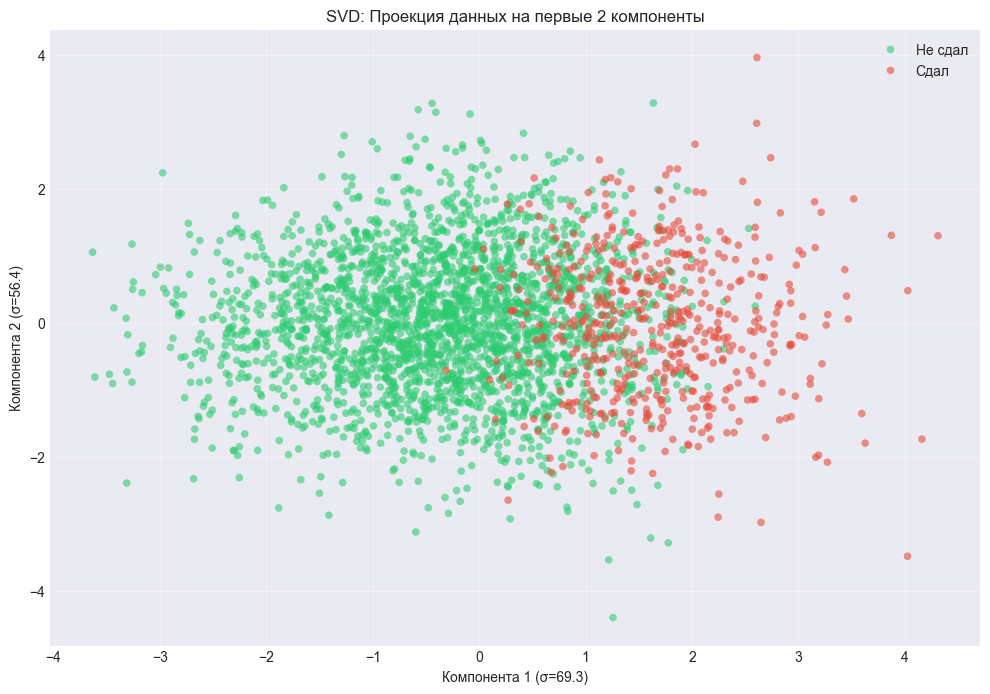

In [9]:
# Визуализация SVD проекции
plt.figure(figsize=(12, 8))
colors = ['#2ecc71', '#e74c3c']
labels_map = {0: 'Не сдал', 1: 'Сдал'}

for label, color in zip([0, 1], colors):
    mask = y == label
    plt.scatter(X_svd_2d[mask, 0], X_svd_2d[mask, 1],
                c=color, label=labels_map[label], alpha=0.6, s=30, edgecolors='none')

plt.xlabel(f'Компонента 1 (σ={sigma[0]:.1f})')
plt.ylabel(f'Компонента 2 (σ={sigma[1]:.1f})')
plt.title('SVD: Проекция данных на первые 2 компоненты')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

SVD проекция идентична PCA. Студенты, сдавшие экзамен, смещены вправо по первой компоненте. Есть зона перекрытия в центре.

## 6. Анализ правых сингулярных векторов (V)

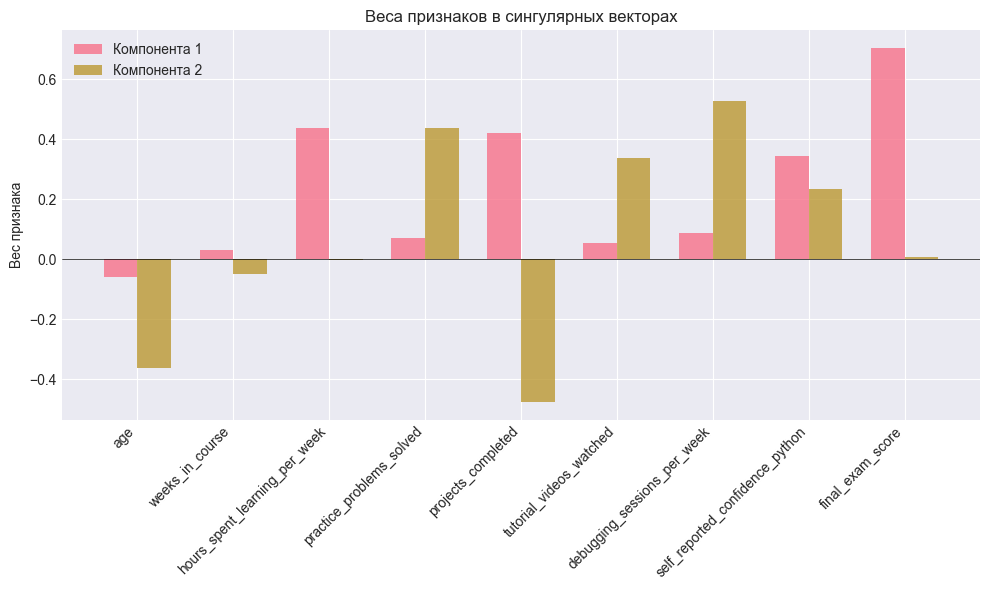

In [10]:
# Веса признаков (правые сингулярные векторы)
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(feature_cols))
width = 0.35

ax.bar(x_pos - width/2, Vt[0], width, label='Компонента 1', alpha=0.8)
ax.bar(x_pos + width/2, Vt[1], width, label='Компонента 2', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_ylabel('Вес признака')
ax.set_title('Веса признаков в сингулярных векторах')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

final_exam_score и self_reported_confidence_python имеют наибольшие веса в первой компоненте. hours_spent_learning_per_week и practice_problems_solved вносят значительный вклад во вторую компоненту.

## 7. Реконструкция данных с усечённым SVD

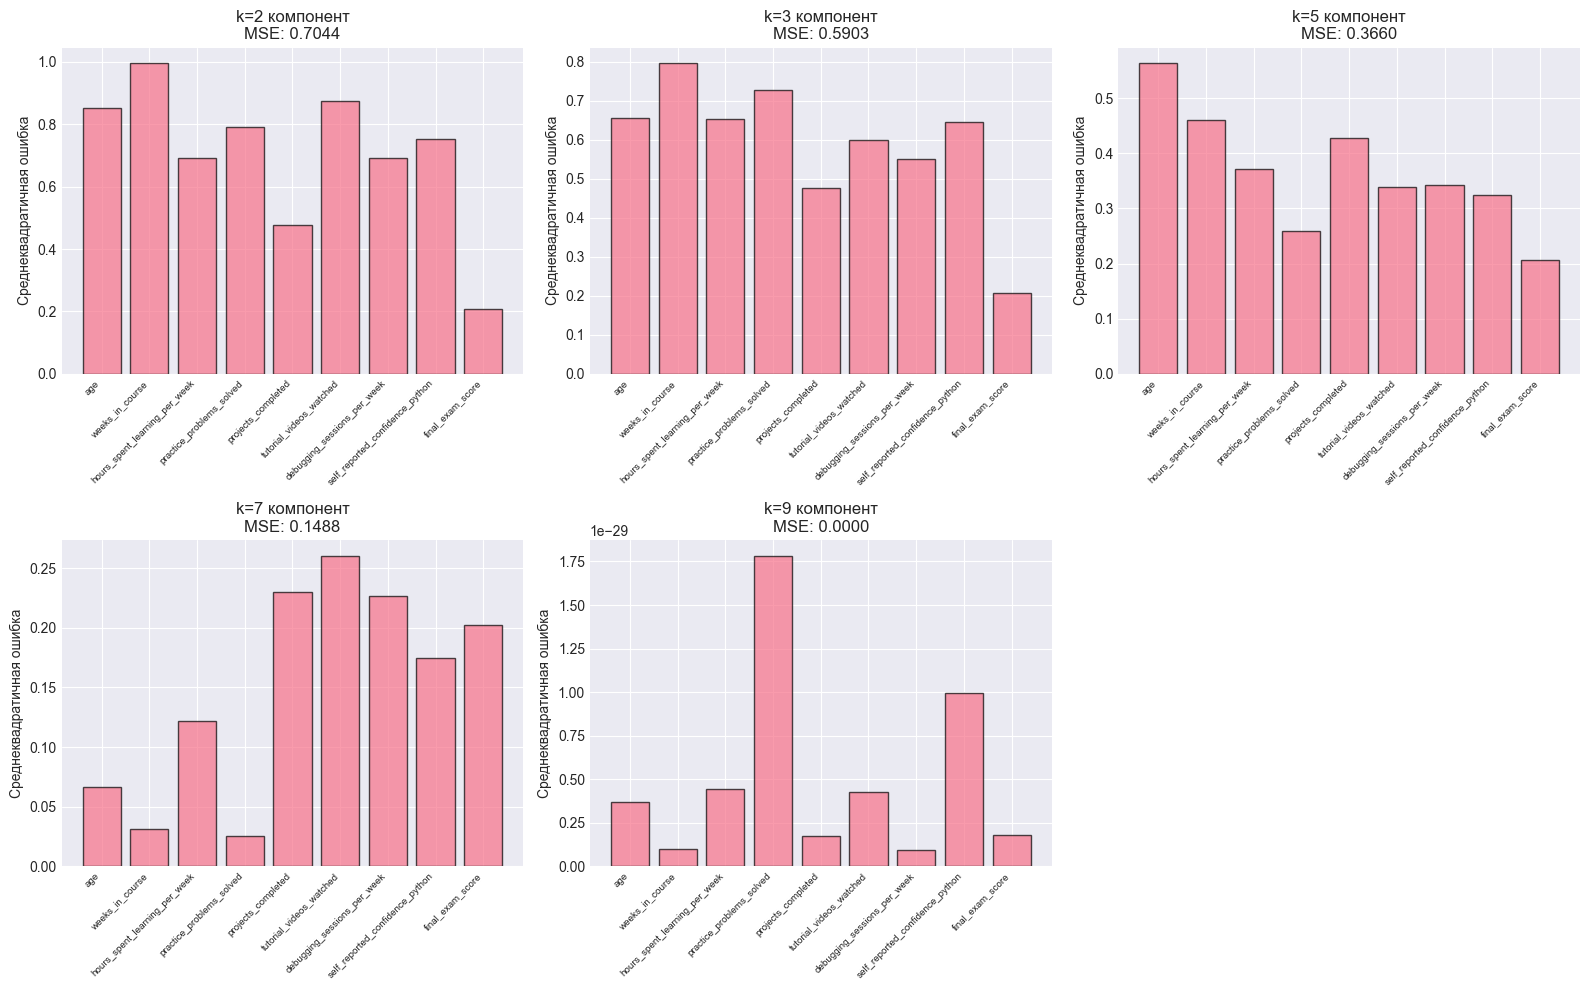

In [11]:
# Реконструкция данных с разным числом компонент
n_components_list = [2, 3, 5, 7, 9]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, k in enumerate(n_components_list):
    # Усечённая реконструкция
    X_reconstructed = U[:, :k] @ np.diag(sigma[:k]) @ Vt[:k, :]
    
    # Ошибка реконструкции
    error = np.mean((X_scaled - X_reconstructed) ** 2)
    
    # Визуализация ошибки по признакам
    feature_errors = np.mean((X_scaled - X_reconstructed) ** 2, axis=0)
    
    axes[idx].bar(range(len(feature_cols)), feature_errors, alpha=0.7, edgecolor='black')
    axes[idx].set_xticks(range(len(feature_cols)))
    axes[idx].set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=7)
    axes[idx].set_title(f'k={k} компонент\nMSE: {error:.4f}')
    axes[idx].set_ylabel('Среднеквадратичная ошибка')

# Пустой subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

 С увеличением числа компонент ошибка реконструкции уменьшается. При k=9 (полное SVD) ошибка равна нулю. При k=2 теряется значительная часть информации.

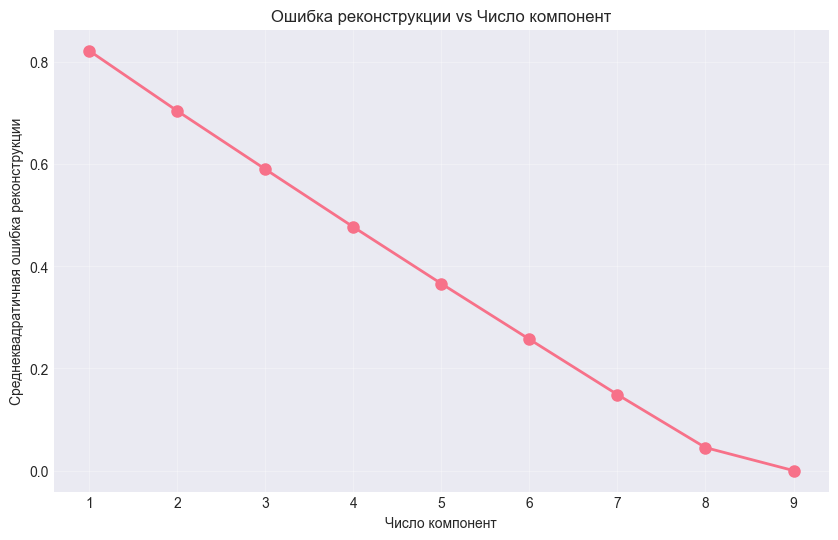

In [12]:
# График ошибки реконструкции от числа компонент
errors = []
for k in range(1, 10):
    X_reconstructed = U[:, :k] @ np.diag(sigma[:k]) @ Vt[:k, :]
    error = np.mean((X_scaled - X_reconstructed) ** 2)
    errors.append(error)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), errors, marker='o', linewidth=2, markersize=8)
plt.xlabel('Число компонент')
plt.ylabel('Среднеквадратичная ошибка реконструкции')
plt.title('Ошибка реконструкции vs Число компонент')
plt.grid(True, alpha=0.3)
plt.show()

Ошибка резко падает при добавлении первых 2-3 компонент. После 5 компонент улучшение незначительное. Это подтверждает, что данные имеют низкую внутреннюю размерность.

## 8. Сравнение проекций SVD и PCA

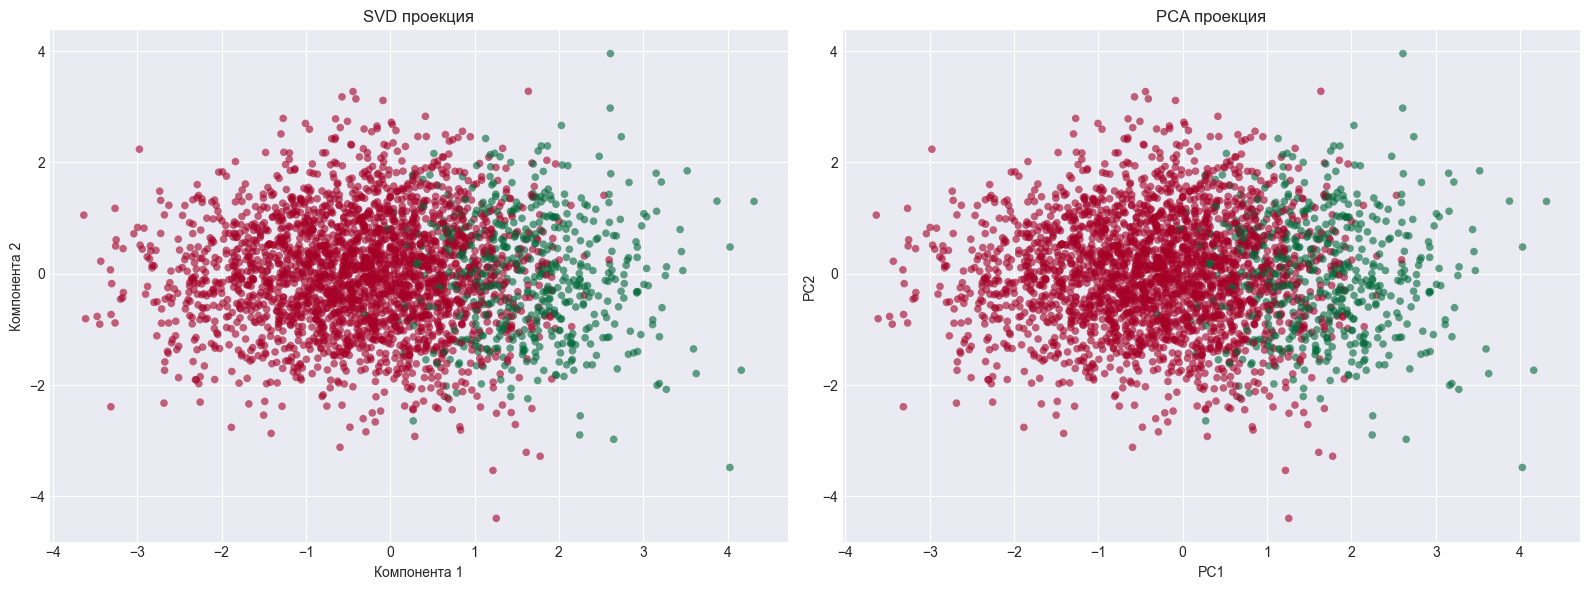

Максимальная разница между SVD и PCA: 0.000000
Средняя разница: 0.000000


In [13]:
# Сравнение проекций SVD и PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SVD
axes[0].scatter(X_svd_2d[:, 0], X_svd_2d[:, 1], c=y, cmap='RdYlGn', alpha=0.6, s=30, edgecolors='none')
axes[0].set_title('SVD проекция')
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')

# PCA
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='RdYlGn', alpha=0.6, s=30, edgecolors='none')
axes[1].set_title('PCA проекция')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# Численное сравнение
diff = np.abs(X_svd_2d - X_pca_2d)
print('Максимальная разница между SVD и PCA:', f'{diff.max():.6f}')
print('Средняя разница:', f'{diff.mean():.6f}')

Проекции SVD и PCA визуально идентичны. Численная разница обусловлена лишь точностью вычислений. Это подтверждает теоретическую эквивалентность методов.